<a href="https://colab.research.google.com/github/gcckd01/Fintech-Support-Intent-Extractor/blob/main/pj2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q -U bitsandbytes transformers peft accelerate datasets trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 16.2 MB/s eta 0:00:00


In [ ]:
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# 1. Set up 4-bit Quantization (This is the 'Q' in QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# 2. Load the Model and Tokenizer
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" # Fast, lightweight model for testing

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Prepare model for PEFT
model = prepare_model_for_kbit_training(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
from datasets import load_dataset

# Load a high-quality fintech customer service dataset
dataset = load_dataset("banking77")

# Take a subset for rapid weekend training
train_data = dataset["train"].select(range(4000))

# We need the human-readable labels, not just the integer IDs
labels = dataset["train"].features["label"].names

# Formatting function: We train the model to output a strict category
def format_banking_instruction(example):
    intent_label = labels[example['label']]
    prompt = f"""<|system|>
You are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.
<|user|>
Customer Ticket: "{example['text']}"
<|assistant|>
Intent: {intent_label}"""
    return {"text": prompt}

# Apply formatting
train_data = train_data.map(format_banking_instruction)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

In [ ]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


In [ ]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./fintech_intent_model",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    save_steps=50,
    logging_steps=10,
    learning_rate=2e-4,
    max_steps=150,
    fp16=False,  # <-- Turned this off
    bf16=True,   # <-- Turned this on to match our model
    max_grad_norm=0.3,
    warmup_steps=5,
    lr_scheduler_type="constant",
    dataset_text_field="text",
    max_length=256,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    processing_class=tokenizer,
    args=training_args,
)

trainer.train()
trainer.model.save_pretrained("tinyllama-fintech-intent")

Step,Training Loss
10,2.058750
20,0.774790
30,0.591425
40,0.545469
50,0.491348
60,0.493174
70,0.465276
80,0.446780
90,0.436094
100,0.439260


In [ ]:
test_ticket = "I tried to buy a coffee this morning but my contactless card just beeped red and declined. I have money in the account!"

prompt = f"""<|system|>
You are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.
<|user|>
Customer Ticket: "{test_ticket}"
<|assistant|>
Intent:"""

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# We add guardrails to the generation process here:
outputs = model.generate(
    **inputs,
    max_new_tokens=15,
    temperature=0.1,          # Makes the model less "creative" and more strict
    do_sample=True,
    repetition_penalty=1.2,   # Strictly punishes the model for repeating tokens like "< < <"
    pad_token_id=tokenizer.eos_token_id,
    use_cache=False           # Gets rid of that annoying warning in your console
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

<|system|>
You are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.
<|user|>
Customer Ticket: "I tried to buy a coffee this morning but my contactless card just beeped red and declined. I have money in the account!"
<|assistant|>
Intent: contactless_not_working


In [ ]:
from trl import SFTTrainer, SFTConfig

# The Production-Ready Config
training_args = SFTConfig(
    output_dir="./fintech_intent_model_full",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    logging_steps=10,
    learning_rate=2e-4,
    num_train_epochs=1,         # <-- Training on the full dataset
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    warmup_ratio=0.03,          # Smoothly ramps up learning
    lr_scheduler_type="cosine", # <-- Smoothly ramps down learning for higher accuracy
    dataset_text_field="text",
    max_length=256,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    processing_class=tokenizer,
    args=training_args,
)

# This will take roughly 15-20 minutes depending on Colab's mood!
trainer.train()
trainer.model.save_pretrained("tinyllama-fintech-intent-FINAL")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
10,0.447406
20,0.445269
30,0.408527
40,0.414253
50,0.395840
60,0.410543
70,0.397151
80,0.394324
90,0.384668
100,0.389774


In [ ]:
# Feel free to change this ticket to something even messier!
test_ticket = "I was at the ATM and the machine literally just swallowed my card. It didn't give me any cash either. Help!"

prompt = f"""<|system|>
You are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.
<|user|>
Customer Ticket: "{test_ticket}"
<|assistant|>
Intent:"""

# Send the prompt to the GPU
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate the prediction with strict guardrails
outputs = model.generate(
    **inputs,
    max_new_tokens=15,
    temperature=0.1,          # Keeps the model highly focused
    do_sample=True,
    repetition_penalty=1.2,   # Prevents the stuttering brackets
    pad_token_id=tokenizer.eos_token_id,
    use_cache=False
)

# Decode the raw output
raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Clean it up for a professional display
predicted_intent = raw_output.split("Intent:")[-1].strip()

print("--- Customer Ticket ---")
print(test_ticket)
print("\n--- AI Categorization ---")
print(f"✅ {predicted_intent}")

--- Customer Ticket ---
I was at the ATM and the machine literally just swallowed my card. It didn't give me any cash either. Help!

--- AI Categorization ---
✅ lost_or_stolen_card


In [ ]:
import gc
import torch
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM
from trl import SFTTrainer, SFTConfig

# 1. Clear out the old model and free up GPU VRAM
try:
    del model
    del trainer
except:
    pass
gc.collect()
torch.cuda.empty_cache()

# 2. Reload the base model fresh
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
model = prepare_model_for_kbit_training(model)

# 3. UPGRADED LoRA Config (The "Brain Expansion")
peft_config_v2 = LoraConfig(
    r=32,          # <-- Doubled the rank (more learning capacity)
    lora_alpha=64, # <-- Scaled up to match the new rank
    # Targeting ALL linear layers now for maximum intelligence
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, peft_config_v2)
print("V2 Trainable Parameters:")
model.print_trainable_parameters()

# 4. UPGRADED Training Config (3 Epochs)
training_args_v2 = SFTConfig(
    output_dir="./fintech_intent_model_v2",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    logging_steps=10,
    learning_rate=2e-4,
    num_train_epochs=3,         # <-- 3 full passes over the data
    fp16=False,
    bf16=True,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    dataset_text_field="text",
    max_length=256,
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    processing_class=tokenizer,
    args=training_args_v2,
)

# Start the V2 Training!
trainer.train()
trainer.model.save_pretrained("tinyllama-fintech-intent-V2")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


V2 Trainable Parameters:
trainable params: 25,231,360 || all params: 1,125,279,744 || trainable%: 2.2422


Step,Training Loss
10,2.513832
20,0.785323
30,0.527386
40,0.478063
50,0.430006
60,0.432675
70,0.420903
80,0.408988
90,0.396208
100,0.400657


In [ ]:
# A list of tricky, real-world customer tickets
test_tickets = [
    "I was at the ATM and the machine literally just swallowed my card. It didn't give me any cash either. Help!",
    "I just woke up and saw a charge for $500 at a Walmart in Texas, but I live in New York and my card is in my wallet!",
    "I transferred rent money to my landlord yesterday morning. It left my account but he says he still hasn't received it.",
    "I'm traveling to Japan next week. Will I be charged extra fees if I use my card to buy things in Yen?"
]

print("🧠 Running V2 Model Batch Inference...\n")

for i, ticket in enumerate(test_tickets, 1):
    # 1. Format the prompt
    prompt = f"""<|system|>
You are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.
<|user|>
Customer Ticket: "{ticket}"
<|assistant|>
Intent:"""

    # 2. Send to GPU
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # 3. Generate prediction
    outputs = model.generate(
        **inputs,
        max_new_tokens=15,
        temperature=0.1,
        do_sample=True,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id,
        use_cache=False
    )

    # 4. Clean up the output
    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predicted_intent = raw_output.split("Intent:")[-1].strip()

    # 5. Display results cleanly
    print(f"--- Ticket {i} ---")
    print(f"User: {ticket}")
    print(f"AI Categorization: ✅ {predicted_intent}\n")

🧠 Running V2 Model Batch Inference...

--- Ticket 1 ---
User: I was at the ATM and the machine literally just swallowed my card. It didn't give me any cash either. Help!
AI Categorization: ✅ pending_cash_withdrawal

--- Ticket 2 ---
User: I just woke up and saw a charge for $500 at a Walmart in Texas, but I live in New York and my card is in my wallet!
AI Categorization: ✅ extra_charge_on_statement

--- Ticket 3 ---
User: I transferred rent money to my landlord yesterday morning. It left my account but he says he still hasn't received it.
AI Categorization: ✅ transfer_not_received_by_recipient

--- Ticket 4 ---
User: I'm traveling to Japan next week. Will I be charged extra fees if I use my card to buy things in Yen?
AI Categorization: ✅ card_payment_fee_charged



In [ ]:
!pip install -q -U bitsandbytes transformers peft accelerate datasets trl matplotlib seaborn

1. Loading Dataset and Tokenizer...
2. Loading Base Model in 4-bit...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

3. Attaching V2 LoRA Adapters...


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


4. Running Fast Re-Training (1 Epoch)...


Step,Training Loss
10,1.983707
20,0.603045
30,0.484165
40,0.461796
50,0.422224
60,0.428737
70,0.416776
80,0.404639
90,0.391514
100,0.397698


Step,Training Loss
10,1.983707
20,0.603045
30,0.484165
40,0.461796
50,0.422224
60,0.428737
70,0.416776
80,0.404639
90,0.391514
100,0.397698


5. Training Complete! Generating LinkedIn Visualization...


/tmp/ipython-input-8849/1858667940.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Count", y="Intent Label", data=intent_counts, palette="viridis")


Text(0.5, 1.0, 'V2 Model Inference: Automated Support Ticket Categorization')

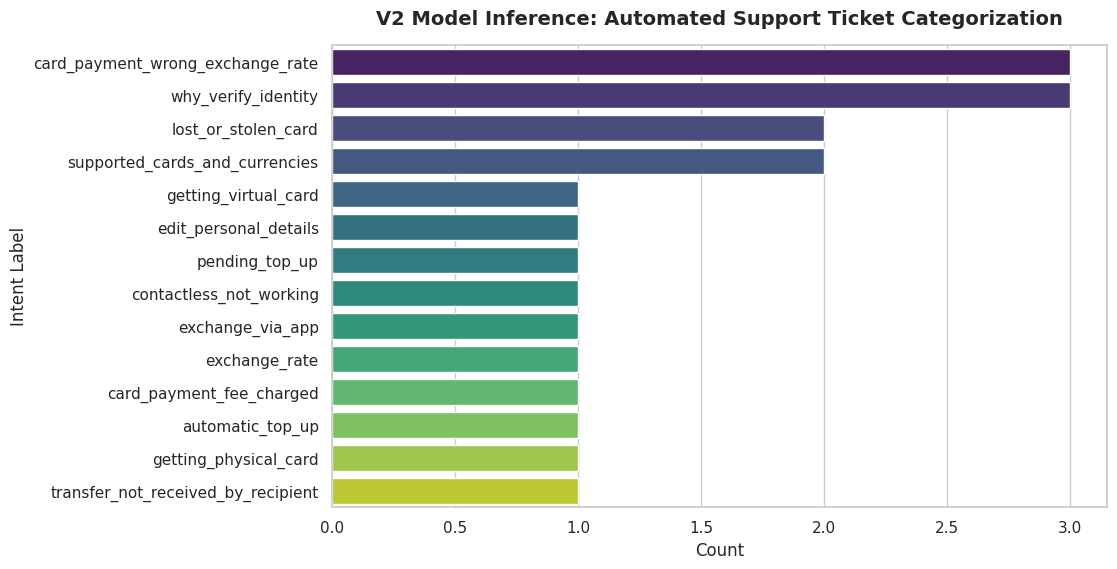

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

print("1. Loading Dataset and Tokenizer...")
dataset = load_dataset("banking77")
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("2. Loading Base Model in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
base_model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
base_model = prepare_model_for_kbit_training(base_model)

print("3. Attaching V2 LoRA Adapters...")
peft_config_v2 = LoraConfig(
    r=32, lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)
model = get_peft_model(base_model, peft_config_v2)

print("4. Running Fast Re-Training (1 Epoch)...")
train_data = dataset["train"].select(range(4000))
def format_banking_instruction(example):
    intent_label = dataset["train"].features["label"].names[example['label']]
    prompt = f"<|system|>\nYou are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.\n<|user|>\nCustomer Ticket: \"{example['text']}\"\n<|assistant|>\nIntent: {intent_label}"
    return {"text": prompt}

train_data = train_data.map(format_banking_instruction)

training_args_v2 = SFTConfig(
    output_dir="./fintech_intent_model_v2",
    per_device_train_batch_size=4, gradient_accumulation_steps=4,
    optim="paged_adamw_32bit", logging_steps=10, learning_rate=2e-4,
    num_train_epochs=1,  # Set to 1 for speed!
    fp16=False, bf16=True, max_grad_norm=0.3, warmup_ratio=0.03,
    lr_scheduler_type="cosine", dataset_text_field="text", max_length=256,
)
trainer = SFTTrainer(model=model, train_dataset=train_data, processing_class=tokenizer, args=training_args_v2)
trainer.train()

print("5. Training Complete! Generating LinkedIn Visualization...")
random.seed(42)
sample_indices = random.sample(range(len(dataset["test"])), 20)
test_batch = [dataset["test"][i]["text"] for i in sample_indices]

results = []
for ticket in test_batch:
    prompt = f"<|system|>\nYou are an AI Product Analyst. Categorize the user's banking issue into a strict intent label.\n<|user|>\nCustomer Ticket: \"{ticket}\"\n<|assistant|>\nIntent:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs, max_new_tokens=15, temperature=0.1,
        do_sample=True, repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id, use_cache=False
    )
    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predicted_intent = raw_output.split("Intent:")[-1].strip()
    results.append(predicted_intent)

df_results = pd.DataFrame({"Intent": results})
intent_counts = df_results["Intent"].value_counts().reset_index()
intent_counts.columns = ["Intent Label", "Count"]

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Count", y="Intent Label", data=intent_counts, palette="viridis")
plt.title("V2 Model Inference: Automated Support Ticket Categorization", fontsize=14, pad=15, fontweight='bold')